# Engagement-filtering audit — Figure 2 / Supp Fig 2 behavior metrics

**Purpose**
1. Report which engagement-related columns actually exist in each saved table (resolves the
   `engaged` vs `engagement_state` question and tells you which code path produced the tables).
2. Quantify how much limiting to *engaged* trials changes the reported metrics, **per experience level**,
   to reveal whether engaged-only filtering introduces a condition-dependent bias.

Run in the `visual_behavior_sdk` env. Reads only the already-saved tables — regenerates nothing.

**The bias being probed:** engagement is defined as rolling reward_rate > 2 rewards/min, and reward_rate
is essentially (recent hits)/time. So "engaged" epochs are by construction the high-hit-rate epochs.
The columns below let you measure how large that inflation is and whether it differs across
Familiar / Novel / Novel+ — which is what would distort a cross-experience comparison.

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

from visual_behavior.data_access import loading
import visual_behavior.visualization.utils as utils

%matplotlib inline
sns.set_context('notebook')
pd.set_option('display.width', 160)
pd.set_option('display.max_columns', 40)

colors = utils.get_experience_level_colors()
exp_order = ['Familiar', 'Novel', 'Novel +']

behavior_metrics_dir = loading.get_performance_metrics_dir()
cache_dir = loading.get_platform_analysis_cache_dir()
metadata_tables_dir = loading.get_metadata_tables_dir()

platform_experiments = pd.read_csv(
    os.path.join(metadata_tables_dir, 'platform_paper_ophys_experiments_table.csv'), index_col=0)
exp_lookup = (platform_experiments[['behavior_session_id', 'experience_level', 'cell_type']]
              .drop_duplicates('behavior_session_id').set_index('behavior_session_id'))

def _try_load_hdf(path):
    return pd.read_hdf(path, key='data') if os.path.exists(path) else None

tables = {}
tables['sdk'] = _try_load_hdf(os.path.join(behavior_metrics_dir, 'sdk_all_sessions.h5'))
tables['stimulus_based_all'] = _try_load_hdf(os.path.join(behavior_metrics_dir, 'stimulus_based_all_sessions.h5'))
tables['stimulus_based_engaged'] = _try_load_hdf(os.path.join(cache_dir, 'stimulus_based_engaged_only_all_sessions.h5'))
p = os.path.join(behavior_metrics_dir, 'platform_behavior_stats_engaged.csv')
tables['platform_behavior_stats_engaged'] = pd.read_csv(p, index_col=0) if os.path.exists(p) else None

def _ensure_bsid(df):
    if df is None:
        return None
    if 'behavior_session_id' not in df.columns:
        df = df.reset_index()
        if 'behavior_session_id' not in df.columns and 'index' in df.columns:
            df = df.rename(columns={'index': 'behavior_session_id'})
    return df

def _add_experience(df):
    df = _ensure_bsid(df)
    if df is None or 'behavior_session_id' not in df.columns:
        return df
    return df.merge(exp_lookup, on='behavior_session_id', how='left')

def _order(idx):
    o = [e for e in exp_order if e in list(idx)]
    return o if o else list(idx)

def _short(labels):
    return [{'Familiar': 'F', 'Novel': 'N', 'Novel +': 'N+'}.get(l, l) for l in labels]

/opt/miniconda3/envs/visual_behavior_sdk/lib/python3.9/site-packages/xarray/__init__.py:1: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources
/opt/miniconda3/envs/visual_behavior_sdk/lib/python3.9/site-packages/requests/__init__.py:86: RequestsDependencyWarning: Unable to find acceptable character detection dependency (chardet or charset_normalizer).
  warnings.warn(
/opt/miniconda3/envs/visual_behavior_sdk/lib/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/Users/marinag/Documents/Code/visual_behavior_analysis/visual_behavior/data_access/from_lims.py:37: UserWarning: failed to set up LIMS/mtrain 

In [2]:
cache_dir

'/Users/marinag/Library/CloudStorage/Dropbox/JupyterNotebooks/FinalDataAssetsforCodeOcean/'

## 1. Column inventory — which engagement column actually got written?

In [3]:
engage_tokens = ['engage', 'engaged', 'reward_rate', 'fraction']
for name, df in tables.items():
    if df is None:
        print(f'\n[{name}]  -- FILE NOT FOUND --'); continue
    cols = list(df.columns)
    engage_cols = [c for c in cols if any(tok in c.lower() for tok in engage_tokens)]
    print(f'\n[{name}]  shape={df.shape}')
    print(f'   engagement-related columns: {engage_cols if engage_cols else "NONE"}')
    print(f'   all columns: {cols}')


[sdk]  shape=(2939, 23)
   engagement-related columns: ['maximum_reward_rate', 'engaged_trial_count', 'mean_hit_rate_engaged', 'mean_false_alarm_rate_engaged', 'mean_dprime_engaged', 'max_dprime_engaged']
   all columns: ['trial_count', 'go_trial_count', 'catch_trial_count', 'hit_trial_count', 'miss_trial_count', 'false_alarm_trial_count', 'correct_reject_trial_count', 'auto_reward_count', 'earned_reward_count', 'total_reward_count', 'total_reward_volume', 'maximum_reward_rate', 'engaged_trial_count', 'mean_hit_rate', 'mean_hit_rate_uncorrected', 'mean_hit_rate_engaged', 'mean_false_alarm_rate', 'mean_false_alarm_rate_uncorrected', 'mean_false_alarm_rate_engaged', 'mean_dprime', 'mean_dprime_engaged', 'max_dprime', 'max_dprime_engaged']

[stimulus_based_all]  shape=(3659, 18)
   engagement-related columns: ['number_of_engaged_go_trials', 'number_of_engaged_hits', 'number_of_engaged_catch_trials', 'number_of_engaged_false_alarms', 'fraction_engaged']
   all columns: ['behavior_session_

## 2. SDK table: engaged vs whole-session, by experience level

These come from one table (the SDK returns both versions of each metric), so it's a clean
within-session comparison.

In [4]:
sdk = _add_experience(tables['sdk'])
if {'engaged_trial_count', 'go_trial_count'}.issubset(sdk.columns):
    sdk['frac_engaged_go'] = sdk['engaged_trial_count'] / sdk['go_trial_count']

pairs = [('mean_hit_rate', 'mean_hit_rate_engaged'),
         ('mean_false_alarm_rate', 'mean_false_alarm_rate_engaged'),
         ('mean_dprime', 'mean_dprime_engaged'),
         ('max_dprime', 'max_dprime_engaged')]
cols_present = [c for pr in pairs for c in pr if c in sdk.columns]
extra = [c for c in ['frac_engaged_go'] if c in sdk.columns]
order = _order(sdk['experience_level'].unique())
sdk_summary = sdk.groupby('experience_level')[cols_present + extra].mean(numeric_only=True).reindex(order)
print('Group means:')
display(sdk_summary.round(3).T)

Group means:


experience_level,Familiar,Novel,Novel +
mean_hit_rate,0.454,0.432,0.469
mean_hit_rate_engaged,0.640,0.681,0.694
mean_false_alarm_rate,0.218,0.183,0.232
mean_false_alarm_rate_engaged,0.310,0.273,0.348
mean_dprime,0.678,0.723,0.672
mean_dprime_engaged,0.982,1.276,1.066
max_dprime,1.524,1.707,1.584
max_dprime_engaged,1.505,1.867,1.694
frac_engaged_go,1.166,1.090,1.287


### Diagnostic plots — SDK

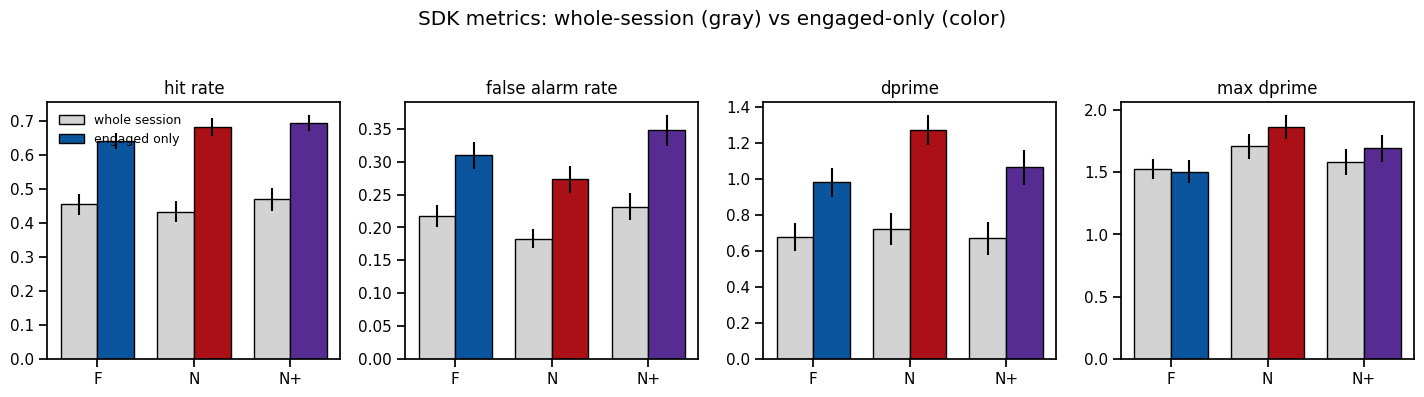

In [5]:
plot_pairs = [(w, e) for (w, e) in pairs if w in sdk.columns and e in sdk.columns]
order = _order(sdk['experience_level'].unique())
x = np.arange(len(order)); bw = 0.38

fig, axes = plt.subplots(1, len(plot_pairs), figsize=(3.6 * len(plot_pairs), 3.8))
if len(plot_pairs) == 1: axes = [axes]
for ax, (whole, eng) in zip(axes, plot_pairs):
    gm_w = sdk.groupby('experience_level')[whole].mean().reindex(order)
    gm_e = sdk.groupby('experience_level')[eng].mean().reindex(order)
    se_w = sdk.groupby('experience_level')[whole].sem().reindex(order)
    se_e = sdk.groupby('experience_level')[eng].sem().reindex(order)
    ax.bar(x - bw/2, gm_w.values, bw, yerr=se_w.values, color='lightgray', edgecolor='k', label='whole session')
    ax.bar(x + bw/2, gm_e.values, bw, yerr=se_e.values, color=colors[:len(order)], edgecolor='k', label='engaged only')
    ax.set_xticks(x); ax.set_xticklabels(_short(order))
    ax.set_title(whole.replace('mean_', '').replace('_', ' '))
axes[0].legend(fontsize=9, frameon=False)
plt.suptitle('SDK metrics: whole-session (gray) vs engaged-only (color)', y=1.04)
plt.tight_layout()
plt.show()

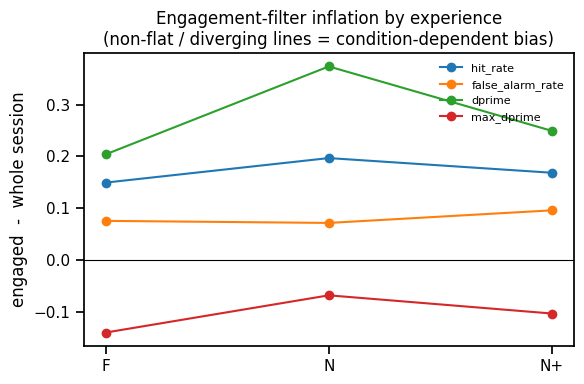

In [6]:
# Condition-dependent inflation: (engaged - whole) by experience. Diverging lines = biased F/N/N+ comparison.
fig, ax = plt.subplots(figsize=(6, 4))
for whole, eng in plot_pairs:
    d = (sdk[eng] - sdk[whole]).groupby(sdk['experience_level']).mean().reindex(order)
    ax.plot(range(len(order)), d.values, '-o', label=eng.replace('_engaged', '').replace('mean_', ''))
ax.axhline(0, color='k', lw=0.8)
ax.set_xticks(range(len(order))); ax.set_xticklabels(_short(order))
ax.set_ylabel('engaged  -  whole session')
ax.set_title('Engagement-filter inflation by experience\n(non-flat / diverging lines = condition-dependent bias)')
ax.legend(fontsize=8, frameon=False)
plt.tight_layout()
plt.show()

## 3. stimulus_based: engaged-only table vs all-trials table, matched by behavior_session_id

In [7]:
all_df = _ensure_bsid(tables['stimulus_based_all'])
eng_df = _ensure_bsid(tables['stimulus_based_engaged'])
metric_cols = []
merged = None
if all_df is not None and eng_df is not None:
    metric_cols = [c for c in ['hit_rate', 'fa_rate', 'dprime_trial_corrected',
                               'dprime_non_trial_corrected', 'response_latency_mean']
                   if c in all_df.columns and c in eng_df.columns]
    merged = all_df[['behavior_session_id'] + metric_cols].merge(
        eng_df[['behavior_session_id'] + metric_cols], on='behavior_session_id', suffixes=('_all', '_engaged'))
    merged = merged.merge(exp_lookup, on='behavior_session_id', how='left')
    order2 = _order(merged['experience_level'].unique())
    delta = pd.DataFrame({c: (merged[f'{c}_engaged'] - merged[f'{c}_all']) for c in metric_cols})
    delta['experience_level'] = merged['experience_level'].values
    print('Per-session (engaged - all) delta, mean by experience level:')
    display(delta.groupby('experience_level').mean().reindex(order2).round(3))
else:
    print('stimulus_based tables not both available; skipping.')

Per-session (engaged - all) delta, mean by experience level:


,hit_rate,fa_rate,dprime_trial_corrected,dprime_non_trial_corrected,response_latency_mean
experience_level,,,,,
Familiar,0.121,0.050,0.100,0.105,0.004
Novel,0.162,0.058,0.157,0.157,0.002
Novel +,0.133,0.052,0.143,0.122,-0.004


### Diagnostic plots — stimulus_based & engagement fraction

/var/folders/1t/06qd1ncj5q90vctbvq586lmh0000gp/T/ipykernel_85659/2596732350.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=d, x='experience_level', y='delta', order=order2,
/var/folders/1t/06qd1ncj5q90vctbvq586lmh0000gp/T/ipykernel_85659/2596732350.py:12: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(_short(order2)); ax.set_xlabel('')
/var/folders/1t/06qd1ncj5q90vctbvq586lmh0000gp/T/ipykernel_85659/2596732350.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=d, x='experience_level', y='delta', order=order2,
/var/folders/1t/06qd1ncj5q90vctbvq586lmh0000gp/T/ipykernel_85659/

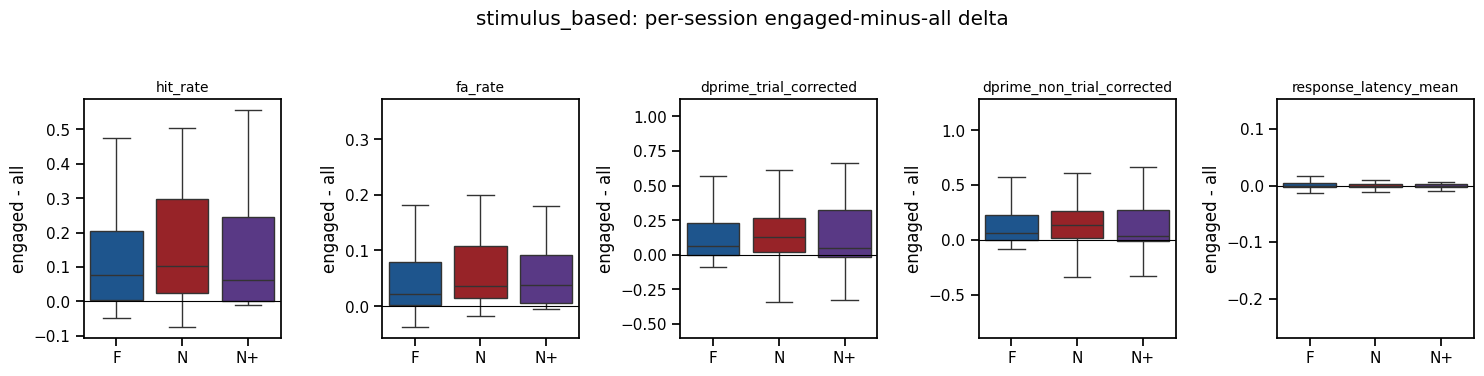

In [8]:
# Per-session engaged-vs-all delta for each metric (boxplots; >0 means engaged filter raises the metric)
if merged is not None and metric_cols:
    order2 = _order(merged['experience_level'].unique())
    fig, axes = plt.subplots(1, len(metric_cols), figsize=(3.0 * len(metric_cols), 3.6))
    if len(metric_cols) == 1: axes = [axes]
    for ax, c in zip(axes, metric_cols):
        d = pd.DataFrame({'delta': merged[f'{c}_engaged'] - merged[f'{c}_all'],
                          'experience_level': merged['experience_level'].values})
        sns.boxplot(data=d, x='experience_level', y='delta', order=order2,
                    palette=colors[:len(order2)], fliersize=0, ax=ax)
        ax.axhline(0, color='k', lw=0.8)
        ax.set_xticklabels(_short(order2)); ax.set_xlabel('')
        ax.set_title(c, fontsize=10); ax.set_ylabel('engaged - all')
    plt.suptitle('stimulus_based: per-session engaged-minus-all delta', y=1.04)
    plt.tight_layout(); plt.show()

/var/folders/1t/06qd1ncj5q90vctbvq586lmh0000gp/T/ipykernel_85659/817104250.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=fe, x='experience_level', y='fraction_engaged', order=order_fe,
/var/folders/1t/06qd1ncj5q90vctbvq586lmh0000gp/T/ipykernel_85659/817104250.py:18: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(_short(order_fe)); ax.set_xlabel('')


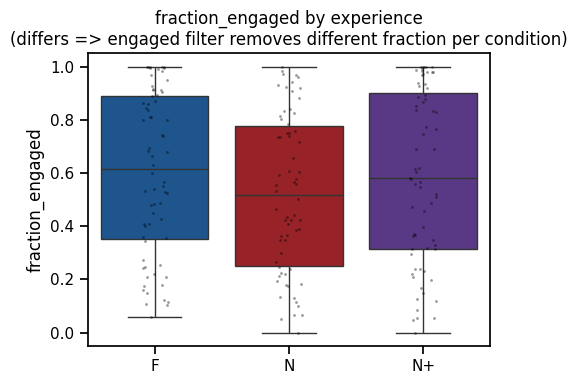

In [9]:
# fraction_engaged by experience: if this differs across conditions, the engaged filter removes a
# different fraction of trials per condition -> the mechanism for condition-dependent bias.
fe_src = None
for src in [all_df, eng_df, _ensure_bsid(tables['platform_behavior_stats_engaged']), sdk]:
    if src is not None and 'fraction_engaged' in getattr(src, 'columns', []):
        fe_src = src; break
if fe_src is None and 'frac_engaged_go' in sdk.columns:
    fe_src = sdk.rename(columns={'frac_engaged_go': 'fraction_engaged'})

if fe_src is not None:
    fe = _add_experience(fe_src)
    order_fe = _order(fe['experience_level'].dropna().unique())
    fig, ax = plt.subplots(figsize=(5, 4))
    sns.boxplot(data=fe, x='experience_level', y='fraction_engaged', order=order_fe,
                palette=colors[:len(order_fe)], fliersize=0, ax=ax)
    sns.stripplot(data=fe, x='experience_level', y='fraction_engaged', order=order_fe,
                  color='k', size=2, alpha=0.4, ax=ax)
    ax.set_xticklabels(_short(order_fe)); ax.set_xlabel('')
    ax.set_title('fraction_engaged by experience\n(differs => engaged filter removes different fraction per condition)')
    plt.tight_layout(); plt.show()
else:
    print('No fraction_engaged column found in any table.')

## How to read these

- **Bars (SDK):** colored (engaged-only) consistently taller than gray (whole-session) = the engaged
  filter inflates the metric. `max_dprime` should be the least affected (it's the whole-session peak).
- **Inflation lines:** if the (engaged - whole) line is *flat* across F/N/N+, the bias is a constant
  offset and the cross-experience comparison is preserved. If it **diverges**, engaged-only filtering
  distorts the F-vs-N comparison itself.
- **stimulus_based delta boxes:** same logic per session; watch for a larger positive shift in one
  experience level than another.
- **fraction_engaged:** if this differs across experience levels, that is the mechanism — engaged-only
  metrics confound "performance when engaged" with "propensity to stay engaged."

If the divergence is meaningful, prefer whole-session metrics (`max_dprime`, whole-session `mean_dprime`)
for the cross-experience comparison, and report `fraction_engaged` separately.

## 4. Forensic check — which engagement definition generated the saved tables?

The engagement definition is fully encoded in `fraction_engaged`. So we can (A) check the saved tables
for internal consistency, then (B) regenerate engagement for a few sessions with the **reward_rate > 2**
definition and see whether it reproduces the saved `fraction_engaged`. A match = the tables used
reward_rate > 2; a mismatch = they used a different definition (e.g. the behavior-model 'engaged' state).

In [10]:
# --- Check A: internal consistency of the SAVED tables (no data reload) ---
all_df = _ensure_bsid(tables['stimulus_based_all'])
eng_df = _ensure_bsid(tables['stimulus_based_engaged'])

print('fraction_engaged in the ENGAGED table')
print('  (if the generator filtered-to-engaged THEN computed fraction, this is ~1.0):')
print('   mean=%.3f  min=%.3f  max=%.3f' % (eng_df['fraction_engaged'].mean(),
       eng_df['fraction_engaged'].min(), eng_df['fraction_engaged'].max()))

print('\nfraction_engaged in the ALL table (the real engaged fraction the definition produced):')
print('   mean=%.3f  min=%.3f  max=%.3f' % (all_df['fraction_engaged'].mean(),
       all_df['fraction_engaged'].min(), all_df['fraction_engaged'].max()))

# Is the engaged go-count a fraction_engaged-sized subset of the all go-count?
m = all_df[['behavior_session_id', 'number_of_engaged_go_trials', 'fraction_engaged']].merge(
    eng_df[['behavior_session_id', 'number_of_engaged_go_trials']],
    on='behavior_session_id', suffixes=('_all', '_eng'))
m['count_ratio'] = m['number_of_engaged_go_trials_eng'] / m['number_of_engaged_go_trials_all']
print('\nPer-session  (engaged go count / all go count)  vs  all-table fraction_engaged:')
print('  median count_ratio                =', round(m['count_ratio'].median(), 3))
print('  median fraction_engaged (all)     =', round(m['fraction_engaged'].median(), 3))
print('  median |ratio - fraction_engaged| =', round((m['count_ratio'] - m['fraction_engaged']).abs().median(), 3))

fraction_engaged in the ENGAGED table
  (if the generator filtered-to-engaged THEN computed fraction, this is ~1.0):
   mean=1.000  min=1.000  max=1.000

fraction_engaged in the ALL table (the real engaged fraction the definition produced):
   mean=0.592  min=0.000  max=1.000

Per-session  (engaged go count / all go count)  vs  all-table fraction_engaged:
  median count_ratio                = 0.689
  median fraction_engaged (all)     = 0.632
  median |ratio - fraction_engaged| = 0.031


In [11]:
# --- Check B: regenerate engagement for a sample of ALREADY-CACHED sessions with reward_rate > 2 ---
# Only loads experiments whose NWB is already in the local SDK cache, so this triggers no new downloads.
# A ~0 difference vs the saved fraction_engaged => the tables used the reward_rate > 2 definition.
import glob, re
import brain_observatory_utilities.datasets.behavior.data_formatting as bf

def cached_ophys_experiment_ids():
    '''ophys_experiment_ids whose NWB file is already downloaded in the local SDK cache.'''
    search_dirs = []
    for getter in ('get_sdk_cache_dir', 'get_platform_analysis_cache_dir'):
        try:
            search_dirs.append(getattr(loading, getter)())
        except Exception:
            pass
    ids = set()
    for d in search_dirs:
        for f in glob.glob(os.path.join(d, '**', 'behavior_ophys_experiment_*.nwb'), recursive=True):
            found = re.search(r'behavior_ophys_experiment_(\d+)\.nwb', os.path.basename(f))
            if found:
                ids.add(int(found.group(1)))
    return ids

cached_ids = cached_ophys_experiment_ids()

# sessions in the saved ALL table that are also platform ophys sessions AND already cached locally
cand = all_df.merge(platform_experiments.reset_index()[['ophys_experiment_id', 'behavior_session_id']],
                    on='behavior_session_id', how='inner').drop_duplicates('behavior_session_id')
cand = cand[cand['ophys_experiment_id'].isin(cached_ids)]
print(len(cand), 'candidate sessions already cached locally')
sample = cand.sample(min(10, len(cand)), random_state=0)

rows = []
for _, r in sample.iterrows():
    print(len(rows) + 1, '/', len(sample))
    bsid, eid = int(r['behavior_session_id']), int(r['ophys_experiment_id'])
    try:
        ds = loading.get_ophys_dataset(eid)
        sp = bf.get_annotated_stimulus_presentations(ds)      # adds engagement_state via reward_rate > 2
        mask = (sp['could_change'] == True)
        if 'auto_rewarded' in sp.columns:
            mask &= (sp['auto_rewarded'] == False)
        frac_rr2 = (sp.loc[mask, 'engagement_state'] == 'engaged').mean()
    except Exception as e:
        frac_rr2 = np.nan
        print(bsid, '-> reward_rate>2 recompute failed:', repr(e))
    rows.append({'behavior_session_id': bsid,
                 'saved_fraction_engaged': float(r['fraction_engaged']),
                 'recomputed_rewardrate_gt2': frac_rr2})

chk = pd.DataFrame(rows)
chk['abs_diff'] = (chk['saved_fraction_engaged'] - chk['recomputed_rewardrate_gt2']).abs()
display(chk.round(3))
print('\nMedian |saved - recomputed(reward_rate>2)| =', round(chk['abs_diff'].median(), 3))
print('~0  => the saved tables used the reward_rate > 2 definition.')
print('large => a DIFFERENT definition was used (next step: test the behavior-model engaged state).')

56 candidate sessions already cached locally
1 / 10


/opt/miniconda3/envs/visual_behavior_sdk/lib/python3.9/site-packages/boto3/compat.py:89: PythonDeprecationWarning: Boto3 will no longer support Python 3.9 starting April 29, 2026. To continue receiving service updates, bug fixes, and security updates please upgrade to Python 3.10 or later. More information can be found here: https://aws.amazon.com/blogs/developer/python-support-policy-updates-for-aws-sdks-and-tools/
  warnings.warn(warning, PythonDeprecationWarning)
/opt/miniconda3/envs/visual_behavior_sdk/lib/python3.9/site-packages/allensdk/brain_observatory/behavior/behavior_project_cache/behavior_project_cache.py:135: UpdatedStimulusPresentationTableWarning: 
	As of AllenSDK version 2.16.0, the latest Visual Behavior Ophys data has been significantly updated from previous releases. Specifically the user will need to update all processing of the stimulus_presentations tables. These tables now include multiple stimulus types delineated by the columns `stimulus_block` and `stimulus_bl

2 / 10


/opt/miniconda3/envs/visual_behavior_sdk/lib/python3.9/site-packages/boto3/compat.py:89: PythonDeprecationWarning: Boto3 will no longer support Python 3.9 starting April 29, 2026. To continue receiving service updates, bug fixes, and security updates please upgrade to Python 3.10 or later. More information can be found here: https://aws.amazon.com/blogs/developer/python-support-policy-updates-for-aws-sdks-and-tools/
  warnings.warn(warning, PythonDeprecationWarning)
/opt/miniconda3/envs/visual_behavior_sdk/lib/python3.9/site-packages/allensdk/brain_observatory/behavior/behavior_project_cache/behavior_project_cache.py:135: UpdatedStimulusPresentationTableWarning: 
	As of AllenSDK version 2.16.0, the latest Visual Behavior Ophys data has been significantly updated from previous releases. Specifically the user will need to update all processing of the stimulus_presentations tables. These tables now include multiple stimulus types delineated by the columns `stimulus_block` and `stimulus_bl

3 / 10


...

/opt/miniconda3/envs/visual_behavior_sdk/lib/python3.9/site-packages/boto3/compat.py:89: PythonDeprecationWarning: Boto3 will no longer support Python 3.9 starting April 29, 2026. To continue receiving service updates, bug fixes, and security updates please upgrade to Python 3.10 or later. More information can be found here: https://aws.amazon.com/blogs/developer/python-support-policy-updates-for-aws-sdks-and-tools/
  warnings.warn(warning, PythonDeprecationWarning)
/opt/miniconda3/envs/visual_behavior_sdk/lib/python3.9/site-packages/allensdk/brain_observatory/behavior/behavior_project_cache/behavior_project_cache.py:135: UpdatedStimulusPresentationTableWarning: 
	As of AllenSDK version 2.16.0, the latest Visual Behavior Ophys data has been significantly updated from previous releases. Specifically the user will need to update all processing of the stimulus_presentations tables. These tables now include multiple stimulus types delineated by the columns `stimulus_block` and `stimulus_bl

10 / 10


/opt/miniconda3/envs/visual_behavior_sdk/lib/python3.9/site-packages/boto3/compat.py:89: PythonDeprecationWarning: Boto3 will no longer support Python 3.9 starting April 29, 2026. To continue receiving service updates, bug fixes, and security updates please upgrade to Python 3.10 or later. More information can be found here: https://aws.amazon.com/blogs/developer/python-support-policy-updates-for-aws-sdks-and-tools/
  warnings.warn(warning, PythonDeprecationWarning)
/opt/miniconda3/envs/visual_behavior_sdk/lib/python3.9/site-packages/allensdk/brain_observatory/behavior/behavior_project_cache/behavior_project_cache.py:135: UpdatedStimulusPresentationTableWarning: 
	As of AllenSDK version 2.16.0, the latest Visual Behavior Ophys data has been significantly updated from previous releases. Specifically the user will need to update all processing of the stimulus_presentations tables. These tables now include multiple stimulus types delineated by the columns `stimulus_block` and `stimulus_bl

,behavior_session_id,saved_fraction_engaged,recomputed_rewardrate_gt2,abs_diff
0,991662910,0.690,0.589,0.101
1,935653479,0.683,0.752,0.069
2,965016824,0.254,NaN,NaN
3,945033994,0.530,0.127,0.402
4,809427293,0.999,0.942,0.057
5,796251270,0.878,0.601,0.277
6,959681045,0.560,0.320,0.240
7,988866696,0.918,0.232,0.685
8,973440813,0.744,0.797,0.053
9,956010809,0.482,0.254,0.227



Median |saved - recomputed(reward_rate>2)| = 0.227
~0  => the saved tables used the reward_rate > 2 definition.
large => a DIFFERENT definition was used (next step: test the behavior-model engaged state).


	behavior_session_id	saved_fraction_engaged	recomputed_rewardrate_gt2	abs_diff
0	991662910	0.690	0.544	0.146
1	935653479	0.683	0.677	0.006
2	965016824	0.254	NaN	NaN
3	945033994	0.530	0.152	0.377
4	809427293	0.999	0.948	0.050
5	796251270	0.878	0.631	0.247
6	959681045	0.560	0.262	0.299
7	988866696	0.918	0.243	0.675
8	973440813	0.744	0.739	0.004
9	956010809	0.482	0.237	0.245


Median |saved - recomputed(reward_rate>2)| = 0.245
~0  => the saved tables used the reward_rate > 2 definition.
large => a DIFFERENT definition was used (next step: test the behavior-model engaged state)

**Interpreting check B**

- If `recomputed_rewardrate_gt2` ≈ `saved_fraction_engaged` for the sampled sessions, the saved tables
  were built with reward_rate > 2 — and `get_annotated_stimulus_presentations` reproduces them, so you
  can regenerate safely with the current code.
- If they diverge, the old tables used a different engagement definition. The most likely alternative is
  the behavior-model 'engaged' state (`loading.add_model_outputs_to_stimulus_presentations`), which we can
  test the same way as a second candidate.

## 5. Generate & validate the new tables (already-cached experiments only)

To avoid triggering slow new NWB downloads, this section only loads ophys experiments whose NWB file
is **already in the local SDK cache**. It writes per-session files + an aggregated `all_sessions.h5`
to a new `stimulus_based_behavior_stats/` folder in the platform cache. The run is resumable, and any
session that fails to load (e.g. the truncated NWBs seen in section 4) lands in `problem_ids`.

In [12]:
import glob, re
import visual_behavior.utilities as vbu

def cached_ophys_experiment_ids():
    '''ophys_experiment_ids whose NWB file is already downloaded in the local SDK cache.'''
    search_dirs = []
    for getter in ('get_sdk_cache_dir', 'get_platform_analysis_cache_dir'):
        try:
            search_dirs.append(getattr(loading, getter)())
        except Exception:
            pass
    ids = set()
    for d in search_dirs:
        for f in glob.glob(os.path.join(d, '**', 'behavior_ophys_experiment_*.nwb'), recursive=True):
            m = re.search(r'behavior_ophys_experiment_(\d+)\.nwb', os.path.basename(f))
            if m:
                ids.add(int(m.group(1)))
    return ids

cached_ids = cached_ophys_experiment_ids()
if 'ophys_experiment_id' in platform_experiments.columns:
    mask = platform_experiments['ophys_experiment_id'].isin(cached_ids)
else:
    mask = platform_experiments.index.isin(cached_ids)
cached_experiments = platform_experiments[mask]
print(len(cached_experiments), 'of', len(platform_experiments),
      'platform experiments already cached locally (no new downloads needed)')

140 of 402 platform experiments already cached locally (no new downloads needed)


In [13]:
# smoke test on a few ALREADY-CACHED experiments (sanity-check columns + values)
n = min(6, len(cached_experiments))
test_df, test_problems = vbu.generate_stimulus_based_behavior_stats_table(
    cached_experiments.sample(n, random_state=1), overwrite=True)

print('problem_ids:', test_problems)
print('\ncolumns produced:'); print(sorted(test_df.columns))
show = ['behavior_session_id', 'fraction_engaged',
        'hit_rate', 'hit_rate_engaged',
        'dprime_trial_corrected', 'dprime_trial_corrected_engaged',
        'max_dprime', 'max_dprime_engaged']
display(test_df[[c for c in show if c in test_df.columns]].round(3))

/opt/miniconda3/envs/visual_behavior_sdk/lib/python3.9/site-packages/boto3/compat.py:89: PythonDeprecationWarning: Boto3 will no longer support Python 3.9 starting April 29, 2026. To continue receiving service updates, bug fixes, and security updates please upgrade to Python 3.10 or later. More information can be found here: https://aws.amazon.com/blogs/developer/python-support-policy-updates-for-aws-sdks-and-tools/
  warnings.warn(warning, PythonDeprecationWarning)
/opt/miniconda3/envs/visual_behavior_sdk/lib/python3.9/site-packages/allensdk/brain_observatory/behavior/behavior_project_cache/behavior_project_cache.py:135: UpdatedStimulusPresentationTableWarning: 
	As of AllenSDK version 2.16.0, the latest Visual Behavior Ophys data has been significantly updated from previous releases. Specifically the user will need to update all processing of the stimulus_presentations tables. These tables now include multiple stimulus types delineated by the columns `stimulus_block` and `stimulus_bl

saved 5 rows to /Users/marinag/Library/CloudStorage/Dropbox/JupyterNotebooks/FinalDataAssetsforCodeOcean/visual_behavior_ophys_analysis_files/stimulus_based_behavior_stats/all_sessions.h5 (0 problem ids)
wrote commit hashes to /Users/marinag/Library/CloudStorage/Dropbox/JupyterNotebooks/FinalDataAssetsforCodeOcean/visual_behavior_ophys_analysis_files/stimulus_based_behavior_stats/all_sessions_commit_hashes.txt
problem_ids: []

columns produced:
['behavior_session_id', 'dprime_non_trial_corrected', 'dprime_non_trial_corrected_engaged', 'dprime_trial_corrected', 'dprime_trial_corrected_engaged', 'fa_rate', 'fa_rate_engaged', 'fraction_engaged', 'fraction_engaged_could_change', 'fraction_engaged_go_trials', 'hit_rate', 'hit_rate_engaged', 'max_dprime', 'max_dprime_engaged', 'mean_dprime', 'mean_dprime_engaged', 'n_catch_opportunities', 'n_catch_opportunities_engaged', 'n_false_alarms', 'n_false_alarms_engaged', 'n_go_opportunities', 'n_go_opportunities_engaged', 'n_hits', 'n_hits_engaged'

,behavior_session_id,fraction_engaged,hit_rate,hit_rate_engaged,dprime_trial_corrected,dprime_trial_corrected_engaged,max_dprime,max_dprime_engaged
0,993984422,0.004,0.035,NaN,0.165,NaN,0.966,NaN
1,876574139,0.659,0.924,0.930,1.788,1.883,2.382,2.382
2,978216799,0.464,0.465,0.546,0.709,0.949,1.701,1.701
3,812955256,0.605,0.469,0.721,1.138,1.534,2.612,2.612
4,850976604,0.495,0.379,0.862,0.769,1.794,2.630,2.630


In [14]:
# validate the smoke-test output against the SDK table for the same sessions
sdk_full = _ensure_bsid(tables['sdk'])
sdk_cols = ['behavior_session_id', 'mean_hit_rate', 'mean_hit_rate_engaged',
            'mean_dprime', 'mean_dprime_engaged', 'max_dprime', 'max_dprime_engaged']
sdk_tab = sdk_full[[c for c in sdk_cols if c in sdk_full.columns]]
cmp = test_df.merge(sdk_tab, on='behavior_session_id', suffixes=('_stim', '_sdk'))

view = pd.DataFrame({
    'bsid': cmp['behavior_session_id'],
    'frac_engaged': cmp['fraction_engaged'],
    'hit_stim': cmp['hit_rate'], 'hit_sdk': cmp['mean_hit_rate'],
    'hit_eng_stim': cmp['hit_rate_engaged'], 'hit_eng_sdk': cmp['mean_hit_rate_engaged'],
    'maxdp_stim': cmp['max_dprime_stim'], 'maxdp_sdk': cmp['max_dprime_sdk'],
    'maxdp_eng_stim': cmp['max_dprime_engaged_stim'], 'maxdp_eng_sdk': cmp['max_dprime_engaged_sdk'],
})
display(view.round(3))

print('Checks:')
print('  fraction_engaged within [0, 1]:',
      bool(((test_df['fraction_engaged'] >= 0) & (test_df['fraction_engaged'] <= 1)).all()))
n_zero = int((test_df['fraction_engaged'] == 0).sum())
print('  sessions with zero engaged stimuli (NaN _engaged cols, expected):', n_zero)
# engaged inflation only well-defined for sessions that have some engaged stimuli
engaged = test_df[test_df['hit_rate_engaged'].notna()]
print('  hit_rate_engaged >= hit_rate (sessions with engagement):',
      bool((engaged['hit_rate_engaged'] >= engaged['hit_rate'] - 1e-9).all()))
print('  max_dprime finite for all:', bool(np.isfinite(test_df['max_dprime']).all()))
if len(cmp) > 2:
    print('  corr(stim max_dprime, sdk max_dprime) =',
          round(cmp['max_dprime_stim'].corr(cmp['max_dprime_sdk']), 3))

,bsid,frac_engaged,hit_stim,hit_sdk,hit_eng_stim,hit_eng_sdk,maxdp_stim,maxdp_sdk,maxdp_eng_stim,maxdp_eng_sdk
0,993984422,0.004,0.035,0.055,NaN,NaN,0.966,0.232,NaN,NaN
1,876574139,0.659,0.924,0.886,0.930,0.897,2.382,1.645,2.382,1.645
2,978216799,0.464,0.465,0.481,0.546,0.507,1.701,1.462,1.701,1.431
3,812955256,0.605,0.469,0.527,0.721,0.551,2.612,2.669,2.612,2.669
4,850976604,0.495,0.379,0.390,0.862,0.545,2.630,2.110,2.630,2.110


Checks:
  fraction_engaged within [0, 1]: True
  sessions with zero engaged stimuli (NaN _engaged cols, expected): 0
  hit_rate_engaged >= hit_rate (sessions with engagement): True
  max_dprime finite for all: True
  corr(stim max_dprime, sdk max_dprime) = 0.938


In [15]:
# # FULL RUN over ALL already-cached experiments (no new downloads). Resumable.
# stim_stats_new, problem_ids = vbu.generate_stimulus_based_behavior_stats_table(cached_experiments)
# print(len(stim_stats_new), 'sessions in table;', len(problem_ids), 'problem ids')
# print('problem ids (e.g. truncated NWBs to delete + re-download):', problem_ids)
# print('saved to:', os.path.join(loading.get_platform_analysis_cache_dir(), 'stimulus_based_behavior_stats'))

**Notes**

- This only covers experiments already on disk. To include the rest, pre-download them (e.g. loop
  `loading.get_ophys_dataset(eid)` over the missing ids, or run the cache's download step) and re-run
  this section — the generator skips sessions already saved.
- Truncated/corrupted NWBs (the `OSError: truncated file` cases from section 4) are still counted as
  "cached" by the file glob, so they'll appear in `problem_ids`. Delete those `.nwb` files so the SDK
  re-downloads clean copies.
- Healthy result: `fraction_engaged in (0,1): True`, `hit_rate_engaged >= hit_rate: True`, and stim vs
  SDK `max_dprime` positively correlated (not identical — the stimulus-based catch definition differs).

## 6. Compare ALL metrics across table types (new / old saved / SDK)

Pulls every metric the new `get_stimulus_based_behavior_stats` produces, aligns each to its best
analog in the old saved stimulus-based files and the SDK table (where one exists), and visualizes the
distribution of every metric as a grid: **rows = table type, columns = metric**, for whole-session and
engaged variants separately.

Correspondence assumptions (edit `CORRESP` below to change them):
- old saved *whole* metrics come from `stimulus_based_all`, old *engaged* from `stimulus_based_engaged`
  (the two legacy files share column names; the new table has both as `x` / `x_engaged`).
- SDK analogs are rolling-window means / peaks with the sparse single-catch-flash FA definition, so they
  are *best analogs*, not identities.
- old `fraction_engaged` (over could-change opportunities) maps to the new `fraction_engaged_could_change`.
- counts map old-only (no clean SDK analog); metrics with no analog show as `n/a`.

In [16]:
# --- load the three sources ---
new_path = os.path.join(loading.get_platform_analysis_cache_dir(),
                        'stimulus_based_behavior_stats', 'all_sessions.h5')
if os.path.exists(new_path):
    new_tab = pd.read_hdf(new_path, key='data')
elif 'stim_stats_new' in globals():
    new_tab = stim_stats_new
else:
    new_tab = test_df
new_tab = _ensure_bsid(new_tab)
old_all = _ensure_bsid(tables['stimulus_based_all'])
old_eng = _ensure_bsid(tables['stimulus_based_engaged'])
sdk_tab = _ensure_bsid(tables['sdk'])

id_cols = {'behavior_session_id', 'ophys_experiment_id', 'image_name'}
new_metric_cols = [c for c in new_tab.columns
                   if c not in id_cols and pd.api.types.is_numeric_dtype(new_tab[c])]
print(len(new_metric_cols), 'metric columns in the NEW table:')
print(sorted(new_metric_cols))
print('\nnew table:', new_tab.shape[0], 'sessions  |  old_all:', old_all.shape[0],
      '|  old_engaged:', old_eng.shape[0], '|  sdk:', sdk_tab.shape[0])

35 metric columns in the NEW table:
['dprime_non_trial_corrected', 'dprime_non_trial_corrected_engaged', 'dprime_trial_corrected', 'dprime_trial_corrected_engaged', 'fa_rate', 'fa_rate_engaged', 'fraction_engaged', 'hit_rate', 'hit_rate_engaged', 'max_dprime', 'max_dprime_engaged', 'n_catch_opportunities', 'n_catch_opportunities_engaged', 'n_false_alarms', 'n_false_alarms_engaged', 'n_go_opportunities', 'n_go_opportunities_engaged', 'n_hits', 'n_hits_engaged', 'response_latency_25%', 'response_latency_25%_engaged', 'response_latency_50%', 'response_latency_50%_engaged', 'response_latency_75%', 'response_latency_75%_engaged', 'response_latency_count', 'response_latency_count_engaged', 'response_latency_max', 'response_latency_max_engaged', 'response_latency_mean', 'response_latency_mean_engaged', 'response_latency_min', 'response_latency_min_engaged', 'response_latency_std', 'response_latency_std_engaged']

new table: 6 sessions  |  old_all: 3659 |  old_engaged: 3822 |  sdk: 2939


In [17]:
# --- correspondence: new metric BASE name -> (old saved col, sdk whole col, sdk engaged col) ---
# old col is read from stimulus_based_all for whole metrics and stimulus_based_engaged for engaged ones.
CORRESP = {
    'hit_rate':                   ('hit_rate',                    'mean_hit_rate',         'mean_hit_rate_engaged'),
    'fa_rate':                    ('fa_rate',                     'mean_false_alarm_rate', 'mean_false_alarm_rate_engaged'),
    'dprime_trial_corrected':     ('dprime_trial_corrected',      'mean_dprime',           'mean_dprime_engaged'),
    'dprime_non_trial_corrected': ('dprime_non_trial_corrected',  None,                    None),
    'max_dprime':                 (None,                          'max_dprime',            'max_dprime_engaged'),
    'mean_dprime':                (None,                          'mean_dprime',           'mean_dprime_engaged'),
    'response_latency_mean':      ('response_latency_mean',       None,                    None),
    'fraction_engaged_could_change': ('fraction_engaged',         None,                    None),
    'n_go_opportunities':         ('number_of_engaged_go_trials',     None, None),
    'n_hits':                     ('number_of_engaged_hits',          None, None),
    'n_catch_opportunities':      ('number_of_engaged_catch_trials',  None, None),
    'n_false_alarms':             ('number_of_engaged_false_alarms',  None, None),
}

def split_variant(col):
    return (col[:-8], 'engaged') if col.endswith('_engaged') else (col, 'whole')

def collect(source, table, value_col, metric, variant):
    if table is None or value_col is None or value_col not in getattr(table, 'columns', []):
        return None
    df = table[['behavior_session_id', value_col]].rename(columns={value_col: 'value'})
    df = df[np.isfinite(df['value'])]
    df['source'], df['metric'], df['variant'] = source, metric, variant
    return df

frames = []
for col in new_metric_cols:
    base, variant = split_variant(col)
    frames.append(collect('new', new_tab, col, base, variant))
    old_col, sdk_w, sdk_e = CORRESP.get(base, (None, None, None))
    if variant == 'whole':
        frames.append(collect('old', old_all, old_col, base, variant))
        frames.append(collect('sdk', sdk_tab, sdk_w, base, variant))
    else:
        frames.append(collect('old', old_eng, old_col, base, variant))
        frames.append(collect('sdk', sdk_tab, sdk_e, base, variant))

tidy = pd.concat([f for f in frames if f is not None], ignore_index=True)
print('coverage (rows = metric/variant, cols = source):')
print(tidy.groupby(['variant', 'metric', 'source']).size().unstack(fill_value=0))

coverage (rows = metric/variant, cols = source):
source                              new   old   sdk
variant metric                                     
engaged dprime_non_trial_corrected    4  2819     0
        dprime_trial_corrected        4  2819  2458
        fa_rate                       4  2820  2459
        fraction                      6     0     0
        hit_rate                      4  2819  2485
        max_dprime                    4     0  2458
        n_catch_opportunities         6  3822     0
        n_false_alarms                6  3822     0
        n_go_opportunities            6  3822     0
        n_hits                        6  3822     0
        response_latency_25%          4     0     0
        response_latency_50%          4     0     0
        response_latency_75%          4     0     0
        response_latency_count        6     0     0
        response_latency_max          4     0     0
        response_latency_mean         4  2780     0
        respons

In [18]:
# --- matched comparison on COMMON sessions: corr + median|delta| of new vs old and new vs sdk ---
def matched_stats(metric, variant):
    sub = tidy[(tidy.metric == metric) & (tidy.variant == variant)]
    wide = sub.pivot_table(index='behavior_session_id', columns='source', values='value', aggfunc='mean')
    out = {'metric': metric, 'variant': variant}
    for ref in ('old', 'sdk'):
        if 'new' in wide.columns and ref in wide.columns:
            both = wide[['new', ref]].dropna()
            out['n_' + ref] = len(both)
            if len(both) > 2:
                out['corr_new_%s' % ref] = round(both['new'].corr(both[ref]), 3)
                out['medabsdiff_new_%s' % ref] = round((both['new'] - both[ref]).abs().median(), 3)
    return out

pairs = tidy[['metric', 'variant']].drop_duplicates().itertuples(index=False)
comparison = pd.DataFrame([matched_stats(m, v) for m, v in pairs])
comparison = comparison.sort_values(['variant', 'metric']).reset_index(drop=True)
display(comparison)

,metric,variant,n_old,corr_new_old,medabsdiff_new_old,n_sdk,corr_new_sdk,medabsdiff_new_sdk
0,dprime_non_trial_corrected,engaged,4.0,0.308,0.648,NaN,NaN,NaN
1,dprime_trial_corrected,engaged,4.0,0.295,0.648,4.0,0.960,0.512
2,fa_rate,engaged,4.0,0.881,0.111,4.0,0.977,0.054
3,fraction,engaged,NaN,NaN,NaN,NaN,NaN,NaN
4,hit_rate,engaged,4.0,0.803,0.111,4.0,0.713,0.105
5,max_dprime,engaged,NaN,NaN,NaN,4.0,0.936,0.157
6,n_catch_opportunities,engaged,5.0,0.825,766.000,NaN,NaN,NaN
7,n_false_alarms,engaged,5.0,0.677,132.000,NaN,NaN,NaN
8,n_go_opportunities,engaged,5.0,0.890,43.000,NaN,NaN,NaN
9,n_hits,engaged,5.0,0.974,12.000,NaN,NaN,NaN


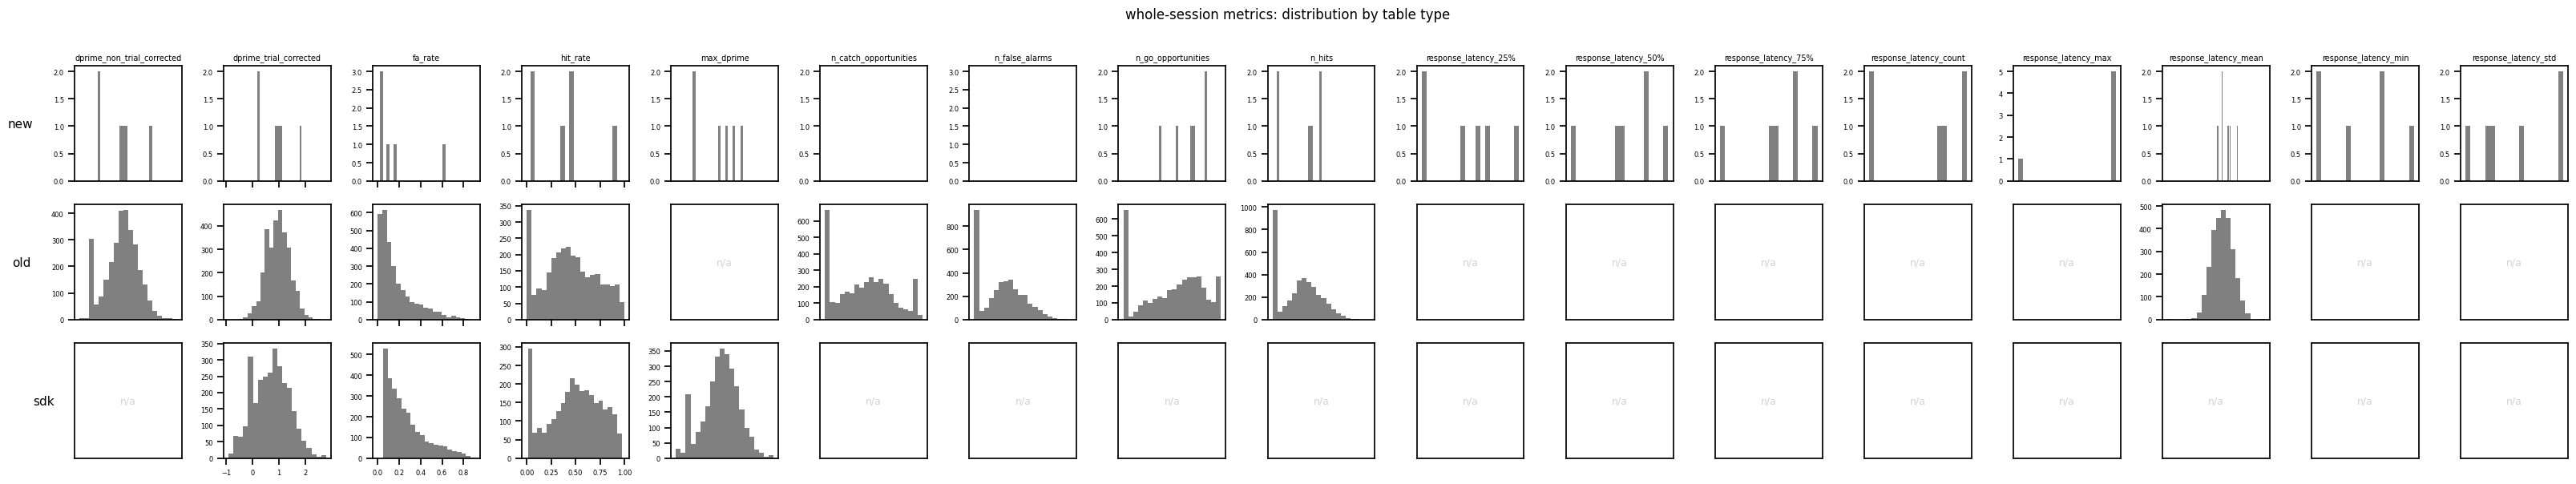

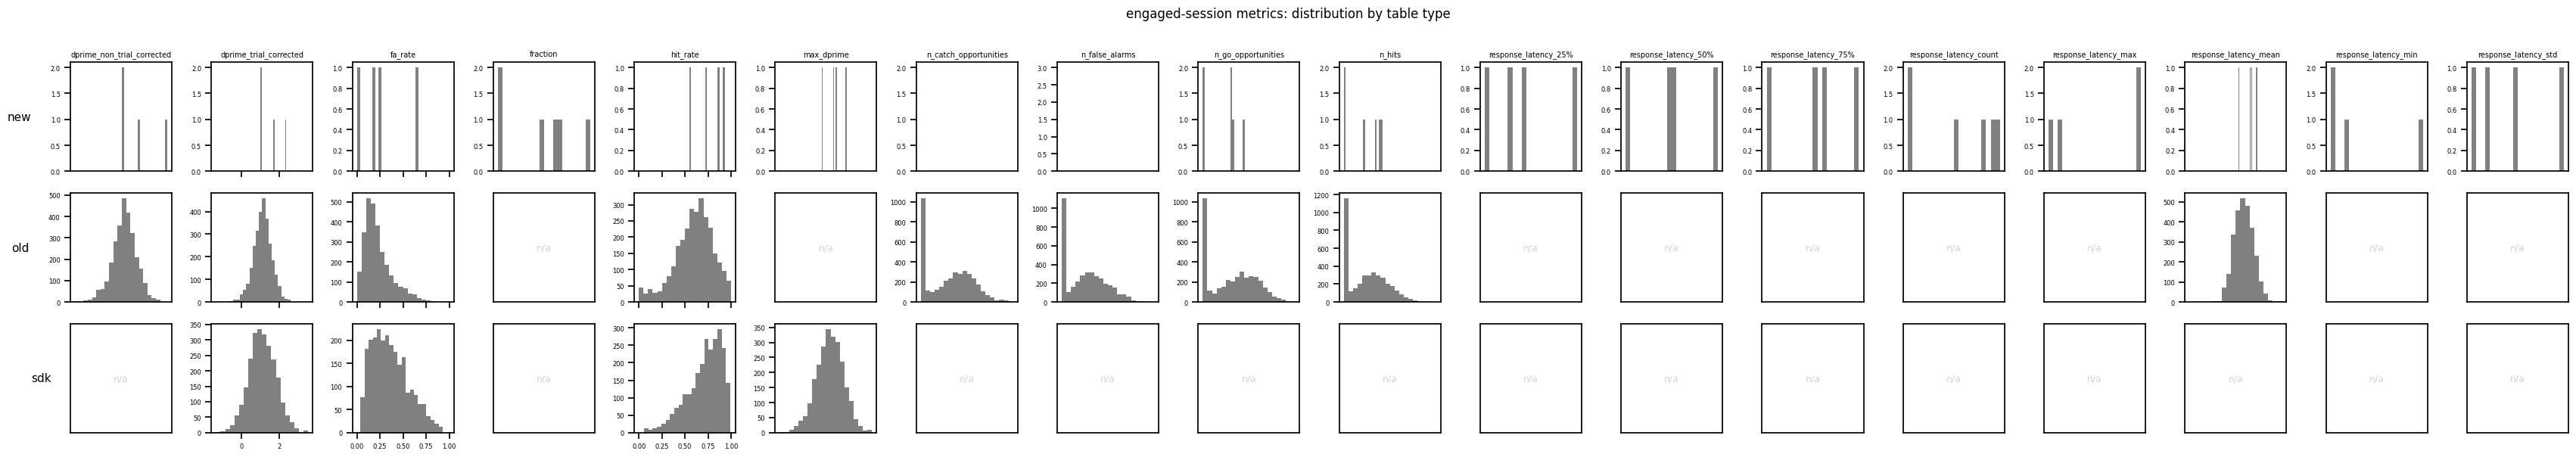

In [19]:
# --- distribution grid: rows = table type, columns = metric ---
def plot_metric_grid(variant, sources=('new', 'old', 'sdk'), metrics=None):
    sub = tidy[tidy.variant == variant]
    if metrics is None:
        metrics = sorted(sub.metric.unique())
    nrows, ncols = len(sources), len(metrics)
    fig, axes = plt.subplots(nrows, ncols, figsize=(1.9 * ncols, 2.0 * nrows),
                             squeeze=False, sharex='col')
    for r, src in enumerate(sources):
        for c, met in enumerate(metrics):
            ax = axes[r][c]
            vals = sub[(sub.source == src) & (sub.metric == met)]['value'].dropna()
            if len(vals) == 0:
                ax.text(0.5, 0.5, 'n/a', ha='center', va='center',
                        transform=ax.transAxes, color='lightgray', fontsize=9)
                ax.set_xticks([]); ax.set_yticks([])
            else:
                ax.hist(vals, bins=20, color='gray', edgecolor='none')
            if r == 0:
                ax.set_title(met, fontsize=7)
            if c == 0:
                ax.set_ylabel(src, fontsize=11, rotation=0, ha='right', va='center', labelpad=18)
            ax.tick_params(labelsize=6)
    plt.suptitle('%s-session metrics: distribution by table type' % variant, y=1.005, fontsize=12)
    plt.tight_layout()
    plt.show()

plot_metric_grid('whole')
plot_metric_grid('engaged')

**How to read**

- Each grid cell is the distribution of one metric (column) within one table type (row); `n/a` means that
  table has no analog for that metric. Columns share an x-axis across the three table rows, so the rows are
  directly comparable. The matched-comparison table above quantifies new-vs-old and new-vs-SDK agreement
  (correlation and median |delta|) on the sessions common to both.
- Expect whole-session metrics (hit_rate, max_dprime, mean_dprime) to agree closely with the SDK; `_engaged`
  metrics to differ more (different engagement masks); and old-vs-new to differ wherever the legacy
  engagement definition diverged (section 4).
- To focus a grid, pass a subset, e.g. `plot_metric_grid('whole', metrics=['hit_rate','fa_rate','max_dprime'])`.
- If the `new` rows look sparse, run the section-5 full generation first so the new table covers more sessions.

## 7. Reward rate computed three ways — which definition should we use?

`engagement_state` is `reward_rate > 2/min`, so the *definition of reward rate* sets which stimuli are
"engaged" and therefore every `_engaged` metric and figure. Two definitions live in the code today, and
they are **not** guaranteed to match:

- **def1 — trial-based (SDK / brain_observatory_utilities).** `calculate_reward_rate` runs over *trials*
  (centered ±25-trial window; a trial counts if `response_latency < 0.75 s`), then each trial's value is
  broadcast onto every flash. This is what `add_reward_rate_to_stimulus_presentations` produces and is
  **the value `engagement_state` is currently thresholded on.** (First 10 trials = `inf` ⇒ always engaged.)
- **def2 — flash-based reward events, flash-count window.** A per-flash boolean `rewarded` (an actual
  reward fell in `[start, start+0.75]`), rolled with a triangular ~320-flash window × `60/0.75`. This is the
  definition coded inside `get_stimulus_based_rolling_performance_df` — but note it only activates if a
  boolean `rewarded` column exists, which the annotated table does **not** currently provide, so in the
  metric code it silently falls back to resampling def1.
- **def3 — reward events over a true time window.** Count actual rewards in a centered N-minute window,
  divided by the window length ⇒ rewards/min. The most literally-physical "rewards per minute".

This section computes all three on a sample of already-cached sessions (no new downloads), then asks:
(a) does def2 (the rolling-table definition) agree with def1 (the engagement definition)? (b) how far is
each from the physical def3? (c) does the choice change `fraction_engaged` differently across F/N/N+
(which is what would bias the cross-experience comparison)?

It also prints a diagnostic on whether `auto_rewarded` is populated on **all** flashes or only change rows
in the annotated table — that determines what the new `fraction_engaged` ("all non-autorewarded") really spans.

In [20]:
# --- the three reward-rate definitions, all returning rewards/min sampled per flash ---
import brain_observatory_utilities.datasets.behavior.data_formatting as bf

FLASH_DUR = 0.75
REWARD_THRESHOLD = 2.0

def per_flash_rewarded(sp, rewards, window=FLASH_DUR):
    """Boolean per flash: did an actual reward occur in [start_time, start_time+window]?"""
    rt = np.sort(rewards['timestamps'].values)
    starts = sp['start_time'].values
    lo = np.searchsorted(rt, starts, side='left')
    hi = np.searchsorted(rt, starts + window, side='right')
    return (hi - lo) > 0

def rr_trial_based(sp):
    """def1: the trial-based reward_rate already on the annotated table (drives engagement today)."""
    return sp['reward_rate'].values.astype(float)

def rr_flash_based(sp, rewarded, window_flashes=320, flash_dur=FLASH_DUR):
    """def2: rolling triangular mean of the per-flash rewarded boolean, scaled to rewards/min."""
    s = pd.Series(np.asarray(rewarded, dtype=float))
    rr = s.rolling(window=window_flashes, min_periods=1, win_type='triang', center=True).mean()
    return (rr * (60.0 / flash_dur)).values

def rr_time_based(sp, rewards, window_min=4.0):
    """def3: actual rewards within a centered time window, per minute (edge windows truncated)."""
    rt = np.sort(rewards['timestamps'].values)
    starts = sp['start_time'].values
    half = window_min * 60.0 / 2.0
    counts = (np.searchsorted(rt, starts + half, side='right') -
              np.searchsorted(rt, starts - half, side='left')).astype(float)
    sess_lo, sess_hi = starts.min(), starts.max()
    covered = (np.minimum(starts + half, sess_hi) - np.maximum(starts - half, sess_lo)) / 60.0
    return counts / np.maximum(covered, 1e-9)


In [21]:
# --- compute all three on a sample of already-cached sessions (no new downloads) ---
# reuse cached_experiments from section 5 if present; otherwise rebuild the cached set
if 'cached_experiments' not in globals():
    import glob, re
    def _cached_oeids():
        ids = set()
        for getter in ('get_sdk_cache_dir', 'get_platform_analysis_cache_dir'):
            try:
                d = getattr(loading, getter)()
            except Exception:
                continue
            for f in glob.glob(os.path.join(d, '**', 'behavior_ophys_experiment_*.nwb'), recursive=True):
                m = re.search(r'behavior_ophys_experiment_(\d+)\.nwb', os.path.basename(f))
                if m:
                    ids.add(int(m.group(1)))
        return ids
    _cids = _cached_oeids()
    _col = 'ophys_experiment_id'
    _mask = (platform_experiments[_col].isin(_cids) if _col in platform_experiments.columns
             else platform_experiments.index.isin(_cids))
    cached_experiments = platform_experiments[_mask]

N_SESSIONS = min(15, len(cached_experiments))
sample_experiments = cached_experiments.drop_duplicates('behavior_session_id').sample(N_SESSIONS, random_state=0)
print(N_SESSIONS, 'sessions sampled from', len(cached_experiments), 'cached experiments')

rows, problem, example = [], [], None
for idx, row in sample_experiments.iterrows():
    bsid = int(row['behavior_session_id'])
    try:
        oeid = int(row['ophys_experiment_id']) if 'ophys_experiment_id' in sample_experiments.columns else int(idx)
        dataset = loading.get_ophys_dataset(oeid)
        sp = bf.get_annotated_stimulus_presentations(dataset)
        rewards = dataset.rewards

        rewarded = per_flash_rewarded(sp, rewards)
        rr = {1: rr_trial_based(sp), 2: rr_flash_based(sp, rewarded), 3: rr_time_based(sp, rewards)}
        eng = {d: rr[d] > REWARD_THRESHOLD for d in (1, 2, 3)}

        # masks computed EXACTLY as production _fraction_engaged does (NaN auto_rewarded -> excluded)
        nonauto = (sp['auto_rewarded'] == False).values            # noqa: E712
        couldchange = nonauto & (sp['could_change'] == True).values  # noqa: E712

        rec = {'behavior_session_id': bsid, 'n_rewards': len(rewards)}
        for d in (1, 2, 3):
            rec['fe_couldchange_def%d' % d] = eng[d][couldchange].mean() if couldchange.any() else np.nan
            rec['fe_nonauto_def%d' % d] = eng[d][nonauto].mean() if nonauto.any() else np.nan
        rec['agree_def2_vs_def1'] = (eng[2] == eng[1]).mean()
        rec['agree_def3_vs_def1'] = (eng[3] == eng[1]).mean()
        # diagnostic: is auto_rewarded populated on ALL flashes, or only change rows?
        rec['n_flashes'] = len(sp)
        rec['n_auto_notnull'] = int(sp['auto_rewarded'].notna().sum())
        rec['n_nonauto_mask'] = int(nonauto.sum())
        rec['n_couldchange_mask'] = int(couldchange.sum())
        rows.append(rec)

        if example is None:
            example = {'bsid': bsid,
                       't': (sp['start_time'].values - sp['start_time'].values[0]) / 60.0,
                       'rr1': rr[1], 'rr2': rr[2], 'rr3': rr[3], 'eng1': eng[1]}
    except Exception as e:
        problem.append((bsid, repr(e)))
        print('failed', bsid, repr(e))

rr_compare = pd.DataFrame(rows)
rr_compare = rr_compare.merge(exp_lookup.reset_index()[['behavior_session_id', 'experience_level']],
                              on='behavior_session_id', how='left')
print(len(rr_compare), 'sessions compared;', len(problem), 'problems')

# auto_rewarded coverage: if n_auto_notnull << n_flashes, "all non-autorewarded" really means only change rows
cov = rr_compare[['n_flashes', 'n_auto_notnull', 'n_nonauto_mask', 'n_couldchange_mask']].sum()
print('\nauto_rewarded coverage across sampled sessions (flash counts summed):')
print('  flashes total          :', int(cov['n_flashes']))
print('  auto_rewarded NOT null :', int(cov['n_auto_notnull']),
      '(%.0f%% of flashes)' % (100 * cov['n_auto_notnull'] / max(cov['n_flashes'], 1)))
print('  non-autorewarded mask  :', int(cov['n_nonauto_mask']),
      '<- denominator of the new "fraction_engaged"')
print('  could_change mask      :', int(cov['n_couldchange_mask']),
      '<- denominator of "fraction_engaged_could_change"')
print('  => if non-autorewarded ~= could_change, auto_rewarded is only on change rows and the two')
print('     fraction_engaged variants span nearly the same stimuli.')
display(rr_compare.round(3))


15 sessions sampled from 140 cached experiments


/opt/miniconda3/envs/visual_behavior_sdk/lib/python3.9/site-packages/boto3/compat.py:89: PythonDeprecationWarning: Boto3 will no longer support Python 3.9 starting April 29, 2026. To continue receiving service updates, bug fixes, and security updates please upgrade to Python 3.10 or later. More information can be found here: https://aws.amazon.com/blogs/developer/python-support-policy-updates-for-aws-sdks-and-tools/
  warnings.warn(warning, PythonDeprecationWarning)
/opt/miniconda3/envs/visual_behavior_sdk/lib/python3.9/site-packages/allensdk/brain_observatory/behavior/behavior_project_cache/behavior_project_cache.py:135: UpdatedStimulusPresentationTableWarning: 
	As of AllenSDK version 2.16.0, the latest Visual Behavior Ophys data has been significantly updated from previous releases. Specifically the user will need to update all processing of the stimulus_presentations tables. These tables now include multiple stimulus types delineated by the columns `stimulus_block` and `stimulus_bl

15 sessions compared; 0 problems

auto_rewarded coverage across sampled sessions (flash counts summed):
  flashes total          : 72034
  auto_rewarded NOT null : 72034 (100% of flashes)
  non-autorewarded mask  : 71216 <- denominator of the new "fraction_engaged"
  could_change mask      : 15016 <- denominator of "fraction_engaged_could_change"
  => if non-autorewarded ~= could_change, auto_rewarded is only on change rows and the two
     fraction_engaged variants span nearly the same stimuli.


,behavior_session_id,n_rewards,fe_couldchange_def1,fe_nonauto_def1,fe_couldchange_def2,fe_nonauto_def2,fe_couldchange_def3,fe_nonauto_def3,agree_def2_vs_def1,agree_def3_vs_def1,n_flashes,n_auto_notnull,n_nonauto_mask,n_couldchange_mask,experience_level
0,849525884,76,0.272,0.329,0.259,0.325,0.253,0.317,0.966,0.957,4810,4810,4750,1112,Familiar
1,1084221839,104,0.449,0.498,0.378,0.395,0.306,0.323,0.845,0.809,4800,4800,4738,960,Familiar
2,884596128,50,0.218,0.239,0.196,0.206,0.190,0.205,0.919,0.951,4798,4798,4735,1199,Novel +
3,956010809,65,0.254,0.284,0.165,0.171,0.060,0.063,0.806,0.775,4805,4805,4748,881,Familiar
4,904922800,109,0.465,0.513,0.344,0.360,0.271,0.302,0.710,0.788,4796,4796,4732,1073,Familiar
5,940628402,139,0.809,0.798,0.747,0.754,0.699,0.706,0.900,0.883,4797,4797,4737,691,Novel +
6,1076649660,44,0.065,0.089,0.012,0.022,0.029,0.037,0.934,0.949,4805,4805,4749,1115,Familiar
7,876574139,126,0.708,0.659,0.538,0.493,0.527,0.463,0.815,0.799,4802,4802,4747,740,Novel +
8,988866696,83,0.232,0.268,0.101,0.126,0.077,0.094,0.824,0.794,4806,4806,4751,879,Familiar
9,1077691596,34,0.137,0.138,0.054,0.070,0.008,0.013,0.860,0.858,4805,4805,4751,1155,Novel


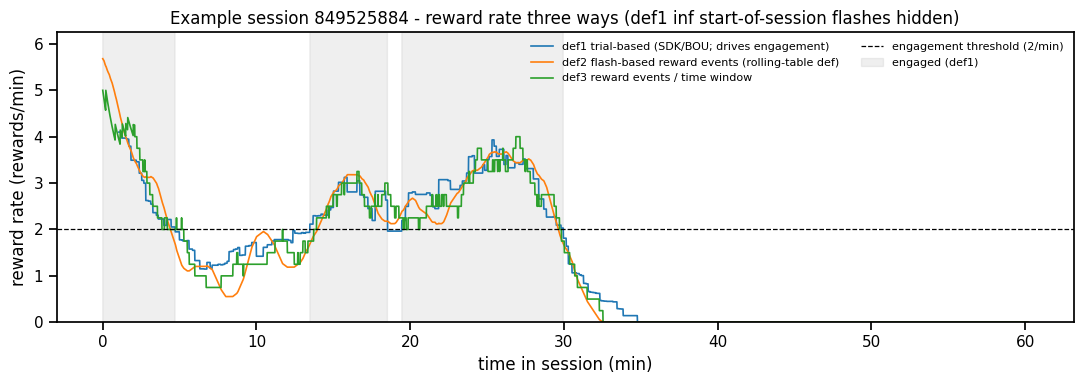

In [22]:
# --- example session: the three rolling reward-rate traces vs the 2/min engagement threshold ---
if example is not None:
    def _finite(a):
        a = np.asarray(a, dtype=float).copy()
        a[~np.isfinite(a)] = np.nan
        return a
    t = example['t']
    r1, r2, r3 = _finite(example['rr1']), _finite(example['rr2']), _finite(example['rr3'])
    ymax = np.nanmax(np.concatenate([r1, r2, r3]))
    ymax = float(ymax) * 1.1 if np.isfinite(ymax) else 10.0

    fig, ax = plt.subplots(figsize=(11, 4))
    ax.plot(t, r1, lw=1.2, label='def1 trial-based (SDK/BOU; drives engagement)')
    ax.plot(t, r2, lw=1.2, label='def2 flash-based reward events (rolling-table def)')
    ax.plot(t, r3, lw=1.2, label='def3 reward events / time window')
    ax.axhline(REWARD_THRESHOLD, color='k', ls='--', lw=0.9, label='engagement threshold (2/min)')
    ax.fill_between(t, 0, ymax, where=example['eng1'], color='gray', alpha=0.12, step='mid',
                    label='engaged (def1)')
    ax.set_ylim(0, ymax)
    ax.set_xlabel('time in session (min)')
    ax.set_ylabel('reward rate (rewards/min)')
    ax.set_title('Example session %d - reward rate three ways '
                 '(def1 inf start-of-session flashes hidden)' % example['bsid'])
    ax.legend(fontsize=8, frameon=False, ncol=2)
    plt.tight_layout(); plt.show()
else:
    print('no example session available (all sampled sessions failed to load)')


Per-flash engaged-label agreement with def1 (the definition driving engagement today):
  def2 (rolling-table)  mean agreement = 0.866
  def3 (events / time)  mean agreement = 0.866


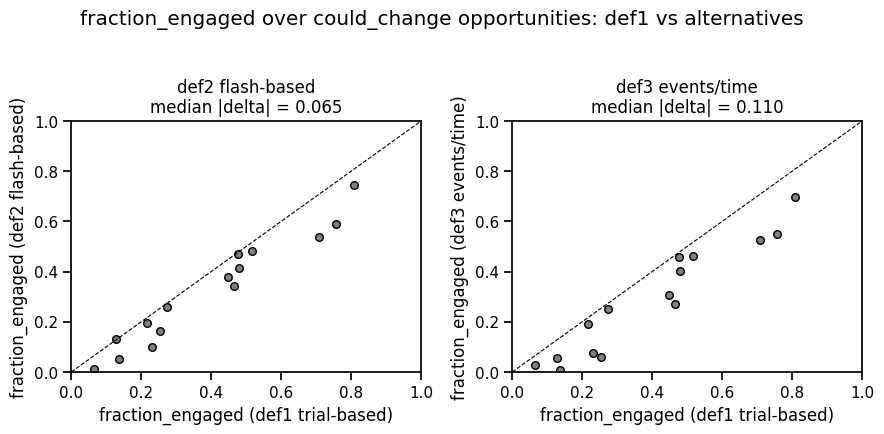

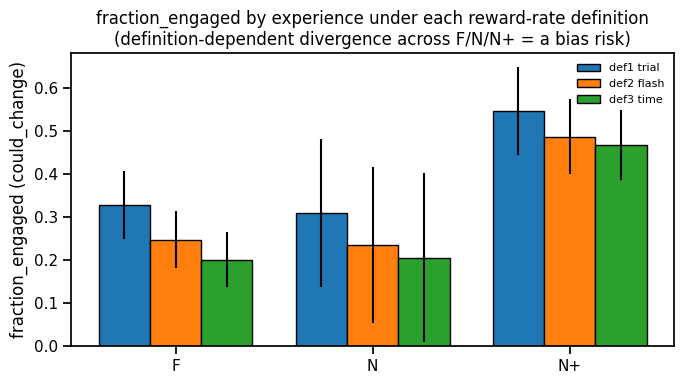

In [23]:
# --- across sessions: agreement with def1, paired scatter, and fraction_engaged by experience ---
print('Per-flash engaged-label agreement with def1 (the definition driving engagement today):')
print('  def2 (rolling-table)  mean agreement = %.3f' % rr_compare['agree_def2_vs_def1'].mean())
print('  def3 (events / time)  mean agreement = %.3f' % rr_compare['agree_def3_vs_def1'].mean())

# (a) fraction_engaged over could_change opportunities: def1 vs each alternative
fig, axes = plt.subplots(1, 2, figsize=(9, 4.2))
for ax, d, lbl in zip(axes, (2, 3), ('def2 flash-based', 'def3 events/time')):
    x, y = rr_compare['fe_couldchange_def1'], rr_compare['fe_couldchange_def%d' % d]
    ax.scatter(x, y, c='gray', edgecolor='k', s=30)
    ax.plot([0, 1], [0, 1], 'k--', lw=0.8)
    ax.set_xlim(0, 1); ax.set_ylim(0, 1)
    ax.set_xlabel('fraction_engaged (def1 trial-based)')
    ax.set_ylabel('fraction_engaged (%s)' % lbl)
    ax.set_title('%s\nmedian |delta| = %.3f' % (lbl, (y - x).abs().median()))
plt.suptitle('fraction_engaged over could_change opportunities: def1 vs alternatives', y=1.03)
plt.tight_layout(); plt.show()

# (b) mean fraction_engaged by experience level under each definition
defs = ['fe_couldchange_def1', 'fe_couldchange_def2', 'fe_couldchange_def3']
labels = ['def1 trial', 'def2 flash', 'def3 time']
order = _order(rr_compare['experience_level'].dropna().unique())
if order:
    means = rr_compare.groupby('experience_level')[defs].mean().reindex(order)
    sems = rr_compare.groupby('experience_level')[defs].sem().reindex(order)
    x = np.arange(len(order)); bw = 0.26
    fig, ax = plt.subplots(figsize=(7, 4))
    for i, (col, lbl) in enumerate(zip(defs, labels)):
        ax.bar(x + (i - 1) * bw, means[col].values, bw, yerr=sems[col].values, label=lbl, edgecolor='k')
    ax.set_xticks(x); ax.set_xticklabels(_short(order))
    ax.set_ylabel('fraction_engaged (could_change)')
    ax.set_title('fraction_engaged by experience under each reward-rate definition\n'
                 '(definition-dependent divergence across F/N/N+ = a bias risk)')
    ax.legend(fontsize=8, frameon=False)
    plt.tight_layout(); plt.show()
else:
    print('no experience_level labels available for the sampled sessions')


**How to read / decision guide**

- **def2-vs-def1 agreement** is the consistency check you flagged: it tells you how often the
  rolling-table reward-rate definition would label a flash's engagement the *same* as the definition all
  the saved metrics actually use. High agreement ⇒ the rolling table and the metrics are effectively
  consistent already; low agreement ⇒ they disagree and we must pick one definition and use it everywhere.
- **Scatter vs the y=x line** shows whether switching to def2 / def3 systematically raises or lowers
  `fraction_engaged`. Points hugging the diagonal ⇒ the choice barely moves engagement; a consistent
  off-diagonal shift ⇒ the 2/min boundary lands in a different place and **every `_engaged` metric and
  figure would change** if we switch.
- **By-experience bars**: if the three definitions agree on the *ordering and gaps* across F / N / N+,
  the choice is scientifically safe for the cross-experience comparison even if absolute values differ.
  If they *reorder or change the gaps*, the definition is load-bearing and must be chosen deliberately.
- **auto_rewarded coverage** (printed above): if `auto_rewarded` is only populated on change rows, the new
  `fraction_engaged` ("all non-autorewarded") spans nearly the same stimuli as `fraction_engaged_could_change`,
  so the two columns will be near-duplicates — worth knowing before relying on the distinction.

**Picking the definition.** def3 (rewards counted over real time) is the most defensible "rewards/min" and
the easiest to state in Methods. def1 is what the paper/threshold were calibrated against. If agreement is
high and the by-experience picture is unchanged, keeping def1 (SDK consistency) is defensible — just document
it. If they diverge materially, switch everything (engagement + rolling table) to one definition (likely def3),
recalibrate the 2/min threshold, regenerate all tables, and update the Methods. To make def2 actually match
def1, the cleanest fix is to add a per-flash boolean `rewarded` to the annotated table in
brain_observatory_utilities and have both engagement and the rolling table read the *same* reward-rate column.

## 8. Verify the BOU column-broadcast fix (trial-type broadcast + change_time)

`get_annotated_stimulus_presentations` now matches the `overhaul_annotate_stim_presentations` design:
trial TYPE (`go`, `catch`, `aborted`, `auto_rewarded`) and `trials_id` are broadcast to **every flash** in a
trial, while trial OUTCOMES (`hit`, `miss`, `false_alarm`, `correct_reject`, `change_time`, `reward_time`,
`reward_volume`) stay on the change / sham-change flash only. This section checks, on a few cached sessions,
that the broadcast actually took effect:

1. **`change_time` ≈ `start_time` on `is_change` flashes** — `change_time` is re-added on change rows only;
   this confirms it equals the change flash's `start_time` (carries no extra per-flash information).
2. **`auto_rewarded` coverage** — should now be non-null on (nearly) **all** flashes, not just change rows
   (only flashes before the first trial start should be NaN). This is the fix working.
3. **could_change 'catch' opportunity set is NOT collapsed** — because `auto_rewarded` is now present on
   non-change flashes, the `auto_rewarded == False` filter in `get_stimulus_based_behavior_stats` no longer
   silently drops them, so the stimulus-based (low-variance, all-flash) FA / could_change definitions are
   genuinely in effect.

In [24]:
import brain_observatory_utilities.datasets.behavior.data_formatting as bf

N_CHECK = min(5, len(cached_experiments))
check_sample = cached_experiments.drop_duplicates('behavior_session_id').sample(N_CHECK, random_state=2)

for idx, row in check_sample.iterrows():
    bsid = int(row['behavior_session_id'])
    try:
        oeid = int(row['ophys_experiment_id']) if 'ophys_experiment_id' in check_sample.columns else int(idx)
        dataset = loading.get_ophys_dataset(oeid)
        trials = dataset.trials.copy()
        if 'change_time' not in trials.columns:
            trials['change_time'] = trials['change_time_no_display_delay']
        sp = bf.get_annotated_stimulus_presentations(dataset)
        print('bsid %d  (%d flashes)' % (bsid, len(sp)))

        # (1) change_time vs start_time on is_change flashes (change_time pulled from trials via trials_id)
        chg = sp[sp['is_change'] == True]
        ct = trials['change_time'].reindex(chg['trials_id'].values).values
        dt = np.abs(chg['start_time'].values - ct)
        print('  (1) is_change flashes=%d  max|start_time - trials.change_time|=%.4f s  median=%.4f s'
              % (len(chg), np.nanmax(dt), np.nanmedian(dt)))

        # (2) auto_rewarded coverage: all flashes vs change vs non-change rows
        nn = int(sp['auto_rewarded'].notna().sum())
        nn_chg = int(sp.loc[sp['is_change'] == True, 'auto_rewarded'].notna().sum())
        nn_non = int(sp.loc[sp['is_change'] == False, 'auto_rewarded'].notna().sum())
        print('  (2) auto_rewarded notnull: %d/%d  (change rows %d, non-change rows %d)'
              % (nn, len(sp), nn_chg, nn_non))

        # (3) does auto_rewarded==False empty the could_change catch set?
        cc = (sp['could_change'] == True) & (sp['is_change'] == False)
        catch_all = int(cc.sum())
        catch_filt = int((cc & (sp['auto_rewarded'] == False)).sum())  # noqa: E712
        n_catch_trials = int((trials.get('catch', pd.Series(dtype=bool)) == True).sum())
        flag = '  <-- COLLAPSES to ~sham-change flashes' if catch_filt < 0.5 * max(catch_all, 1) else ''
        print('  (3) catch opportunities: could_change&~is_change=%d   after auto_rewarded==False=%d   '
              '(catch trials=%d)%s' % (catch_all, catch_filt, n_catch_trials, flag))
    except Exception as e:
        print('bsid', bsid, 'failed', repr(e))


/opt/miniconda3/envs/visual_behavior_sdk/lib/python3.9/site-packages/boto3/compat.py:89: PythonDeprecationWarning: Boto3 will no longer support Python 3.9 starting April 29, 2026. To continue receiving service updates, bug fixes, and security updates please upgrade to Python 3.10 or later. More information can be found here: https://aws.amazon.com/blogs/developer/python-support-policy-updates-for-aws-sdks-and-tools/
  warnings.warn(warning, PythonDeprecationWarning)
/opt/miniconda3/envs/visual_behavior_sdk/lib/python3.9/site-packages/allensdk/brain_observatory/behavior/behavior_project_cache/behavior_project_cache.py:135: UpdatedStimulusPresentationTableWarning: 
	As of AllenSDK version 2.16.0, the latest Visual Behavior Ophys data has been significantly updated from previous releases. Specifically the user will need to update all processing of the stimulus_presentations tables. These tables now include multiple stimulus types delineated by the columns `stimulus_block` and `stimulus_bl

bsid 966835517  (4808 flashes)
  (1) is_change flashes=202  max|start_time - trials.change_time|=0.0000 s  median=0.0000 s
  (2) auto_rewarded notnull: 4808/4808  (change rows 202, non-change rows 4606)
  (3) catch opportunities: could_change&~is_change=658   after auto_rewarded==False=650   (catch trials=26)


/opt/miniconda3/envs/visual_behavior_sdk/lib/python3.9/site-packages/boto3/compat.py:89: PythonDeprecationWarning: Boto3 will no longer support Python 3.9 starting April 29, 2026. To continue receiving service updates, bug fixes, and security updates please upgrade to Python 3.10 or later. More information can be found here: https://aws.amazon.com/blogs/developer/python-support-policy-updates-for-aws-sdks-and-tools/
  warnings.warn(warning, PythonDeprecationWarning)
/opt/miniconda3/envs/visual_behavior_sdk/lib/python3.9/site-packages/allensdk/brain_observatory/behavior/behavior_project_cache/behavior_project_cache.py:135: UpdatedStimulusPresentationTableWarning: 
	As of AllenSDK version 2.16.0, the latest Visual Behavior Ophys data has been significantly updated from previous releases. Specifically the user will need to update all processing of the stimulus_presentations tables. These tables now include multiple stimulus types delineated by the columns `stimulus_block` and `stimulus_bl

bsid 962984229  (4806 flashes)
  (1) is_change flashes=234  max|start_time - trials.change_time|=0.0000 s  median=0.0000 s
  (2) auto_rewarded notnull: 4806/4806  (change rows 234, non-change rows 4572)
  (3) catch opportunities: could_change&~is_change=742   after auto_rewarded==False=736   (catch trials=34)


/opt/miniconda3/envs/visual_behavior_sdk/lib/python3.9/site-packages/boto3/compat.py:89: PythonDeprecationWarning: Boto3 will no longer support Python 3.9 starting April 29, 2026. To continue receiving service updates, bug fixes, and security updates please upgrade to Python 3.10 or later. More information can be found here: https://aws.amazon.com/blogs/developer/python-support-policy-updates-for-aws-sdks-and-tools/
  warnings.warn(warning, PythonDeprecationWarning)
/opt/miniconda3/envs/visual_behavior_sdk/lib/python3.9/site-packages/allensdk/brain_observatory/behavior/behavior_project_cache/behavior_project_cache.py:135: UpdatedStimulusPresentationTableWarning: 
	As of AllenSDK version 2.16.0, the latest Visual Behavior Ophys data has been significantly updated from previous releases. Specifically the user will need to update all processing of the stimulus_presentations tables. These tables now include multiple stimulus types delineated by the columns `stimulus_block` and `stimulus_bl

bsid 956010809  (4805 flashes)
  (1) is_change flashes=237  max|start_time - trials.change_time|=0.0000 s  median=0.0000 s
  (2) auto_rewarded notnull: 4805/4805  (change rows 237, non-change rows 4568)
  (3) catch opportunities: could_change&~is_change=659   after auto_rewarded==False=652   (catch trials=33)


/opt/miniconda3/envs/visual_behavior_sdk/lib/python3.9/site-packages/boto3/compat.py:89: PythonDeprecationWarning: Boto3 will no longer support Python 3.9 starting April 29, 2026. To continue receiving service updates, bug fixes, and security updates please upgrade to Python 3.10 or later. More information can be found here: https://aws.amazon.com/blogs/developer/python-support-policy-updates-for-aws-sdks-and-tools/
  warnings.warn(warning, PythonDeprecationWarning)
/opt/miniconda3/envs/visual_behavior_sdk/lib/python3.9/site-packages/allensdk/brain_observatory/behavior/behavior_project_cache/behavior_project_cache.py:135: UpdatedStimulusPresentationTableWarning: 
	As of AllenSDK version 2.16.0, the latest Visual Behavior Ophys data has been significantly updated from previous releases. Specifically the user will need to update all processing of the stimulus_presentations tables. These tables now include multiple stimulus types delineated by the columns `stimulus_block` and `stimulus_bl

bsid 854283407  (4804 flashes)
  (1) is_change flashes=339  max|start_time - trials.change_time|=0.0000 s  median=0.0000 s
  (2) auto_rewarded notnull: 4804/4804  (change rows 339, non-change rows 4465)
  (3) catch opportunities: could_change&~is_change=991   after auto_rewarded==False=979   (catch trials=48)


/opt/miniconda3/envs/visual_behavior_sdk/lib/python3.9/site-packages/boto3/compat.py:89: PythonDeprecationWarning: Boto3 will no longer support Python 3.9 starting April 29, 2026. To continue receiving service updates, bug fixes, and security updates please upgrade to Python 3.10 or later. More information can be found here: https://aws.amazon.com/blogs/developer/python-support-policy-updates-for-aws-sdks-and-tools/
  warnings.warn(warning, PythonDeprecationWarning)
/opt/miniconda3/envs/visual_behavior_sdk/lib/python3.9/site-packages/allensdk/brain_observatory/behavior/behavior_project_cache/behavior_project_cache.py:135: UpdatedStimulusPresentationTableWarning: 
	As of AllenSDK version 2.16.0, the latest Visual Behavior Ophys data has been significantly updated from previous releases. Specifically the user will need to update all processing of the stimulus_presentations tables. These tables now include multiple stimulus types delineated by the columns `stimulus_block` and `stimulus_bl

bsid 1075912006  (4798 flashes)
  (1) is_change flashes=320  max|start_time - trials.change_time|=0.0000 s  median=0.0000 s
  (2) auto_rewarded notnull: 4798/4798  (change rows 320, non-change rows 4478)
  (3) catch opportunities: could_change&~is_change=876   after auto_rewarded==False=871   (catch trials=43)


**Interpreting section 8 (post-fix expectations)**

- **(1)** `max|start_time - change_time|` ≈ 0 (or a tiny constant display lag) confirms `change_time` on the
  change flash is just its `start_time`.
- **(2)** `auto_rewarded` should now be non-null on ~all flashes (non-change rows ≫ 0; only pre-first-trial
  flashes NaN). If non-change rows are still ≈ 0, the broadcast didn't take effect — check that
  `add_trial_type_to_stimulus_presentations` ran and `trials_id` is populated on all flashes.
- **(3)** `could_change & ~is_change` and its `& auto_rewarded==False` count should now be ≈ equal (no
  collapse). That means `get_stimulus_based_behavior_stats._opportunity_metrics` / `_fraction_engaged`
  operate over every could_change opportunity (the intended low-variance FA definition), and the new
  `fraction_engaged` ('all non-autorewarded') genuinely spans all non-autorewarded flashes — **no change to
  `get_stimulus_based_behavior_stats` is needed.**